# Telco Customer Churn Analysis

**End-to-end Data Analytics & Machine Learning project**

This notebook covers data inspection, cleaning, EDA, churn analysis, statistical testing, customer segmentation, machine-learning prediction, evaluation, feature importance, and business recommendations.


In [1]:
# Install if needed:
# %pip install pandas numpy matplotlib seaborn scikit-learn scipy

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.stats import chi2_contingency, ttest_ind
from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, confusion_matrix, classification_report, roc_curve
)
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)


Matplotlib is building the font cache; this may take a moment.


## 1. Load and Inspect the Dataset

In [3]:
CSV_PATH = r"WA_Fn-UseC_-Telco-Customer-Churn.csv"
df = pd.read_csv(CSV_PATH)

print("Shape:", df.shape)
display(df.head())
display(df.info())

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

None

## 2. Data Cleaning

In [4]:
# TotalCharges is numeric data stored as text. Blank values become NaN.
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")

# Helpful analysis labels
df["SeniorCitizenLabel"] = df["SeniorCitizen"].map({0: "No", 1: "Yes"})
df["ChurnBinary"] = df["Churn"].map({"No": 0, "Yes": 1})

print("Missing TotalCharges:", df["TotalCharges"].isna().sum())
display(df[["tenure", "MonthlyCharges", "TotalCharges"]].describe().T)


Missing TotalCharges: 11


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


## 3. Overall Churn

,Customers,Percentage
Churn,,
No,5174,73.46
Yes,1869,26.54


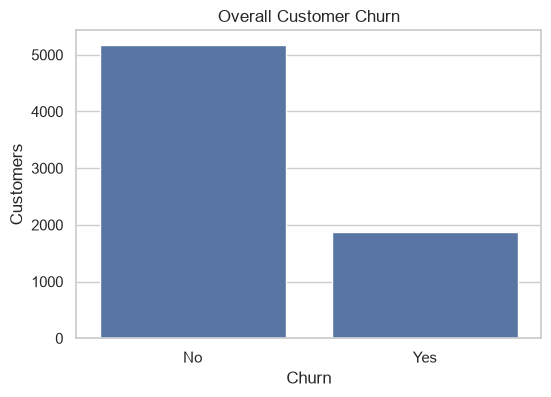

In [5]:
summary = pd.DataFrame({
    "Customers": df["Churn"].value_counts(),
    "Percentage": df["Churn"].value_counts(normalize=True).mul(100).round(2)
})
display(summary)

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Churn")
plt.title("Overall Customer Churn")
plt.xlabel("Churn")
plt.ylabel("Customers")
plt.show()


## 4. Descriptive Statistics

In [6]:
numeric_cols = ["tenure", "MonthlyCharges", "TotalCharges"]

display(df[numeric_cols].describe().T)
display(df.groupby("Churn")[numeric_cols].mean().round(2).T)


,count,mean,std,min,25%,50%,75%,max
tenure,7043.0,32.371149,24.559481,0.00,9.00,29.000,55.0000,72.00
MonthlyCharges,7043.0,64.761692,30.090047,18.25,35.50,70.350,89.8500,118.75
TotalCharges,7032.0,2283.300441,2266.771362,18.80,401.45,1397.475,3794.7375,8684.80


Churn,No,Yes
tenure,37.57,17.98
MonthlyCharges,61.27,74.44
TotalCharges,2555.34,1531.80


## 5. Univariate Analysis

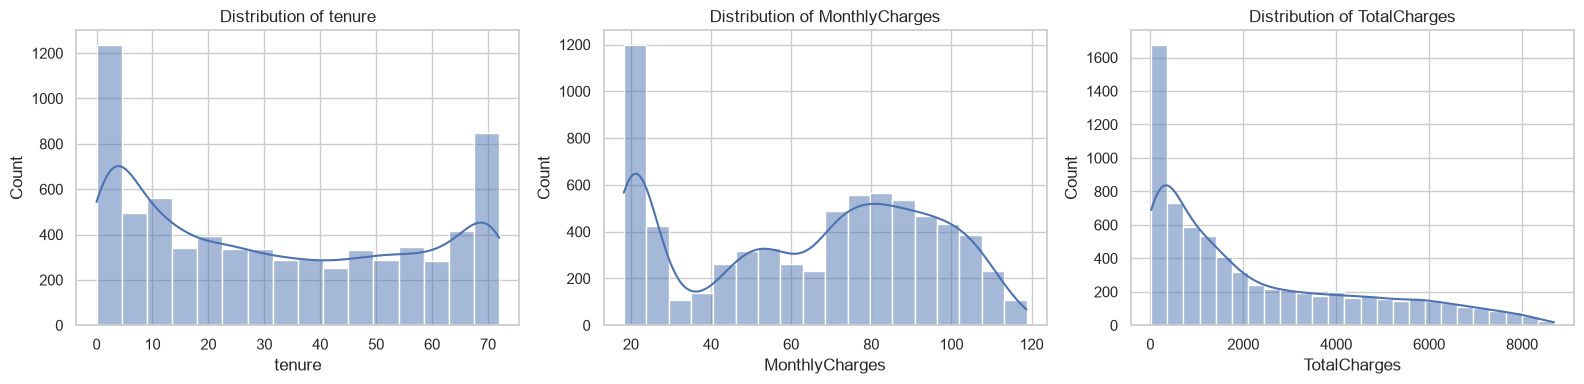

In [7]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, col in zip(axes, numeric_cols):
    sns.histplot(data=df, x=col, kde=True, ax=ax)
    ax.set_title(f"Distribution of {col}")

plt.tight_layout()
plt.show()


## 6. Churn by Key Categorical Variables

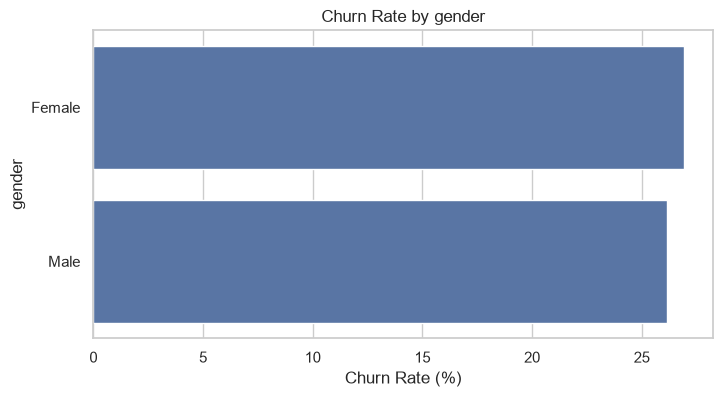

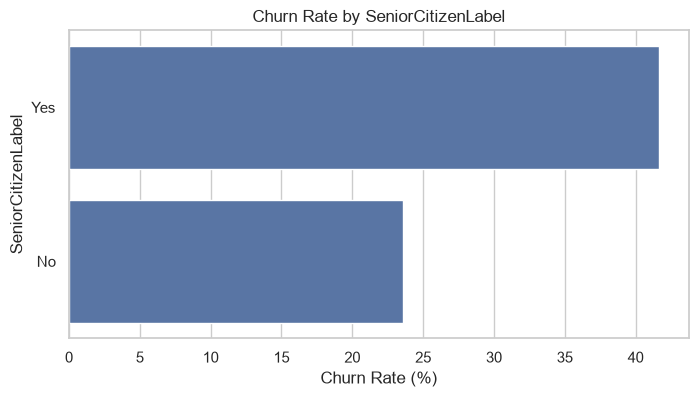

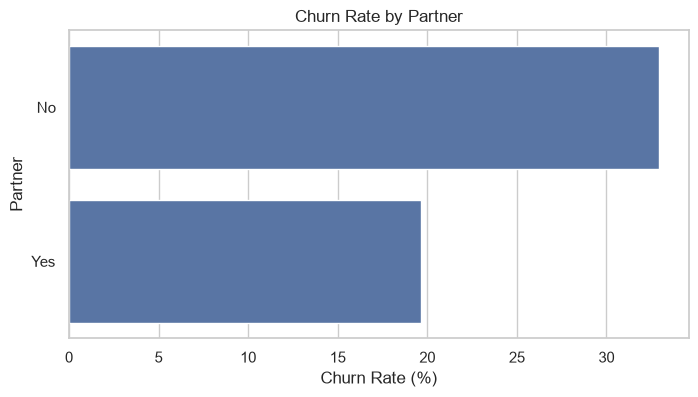

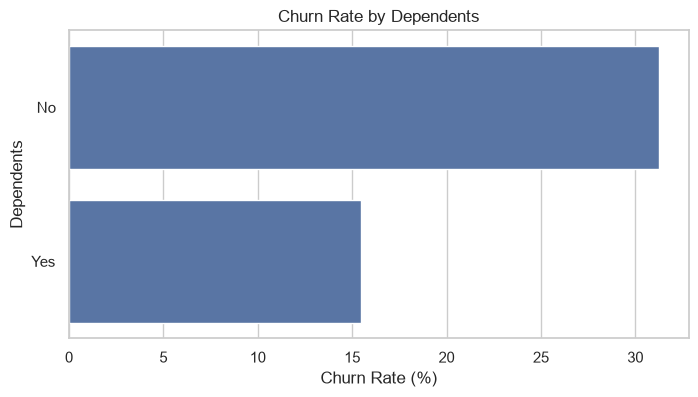

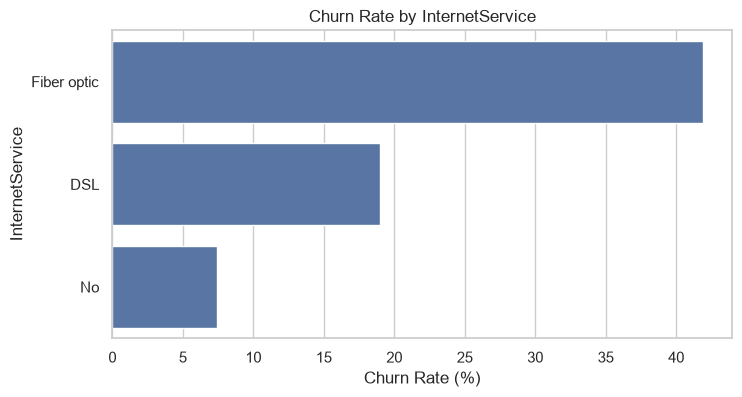

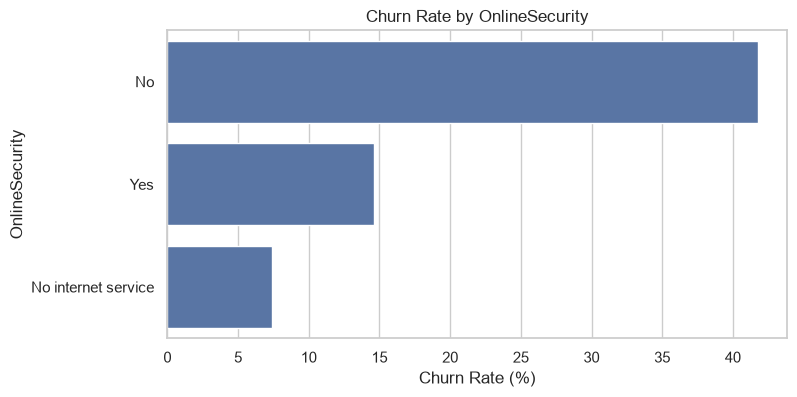

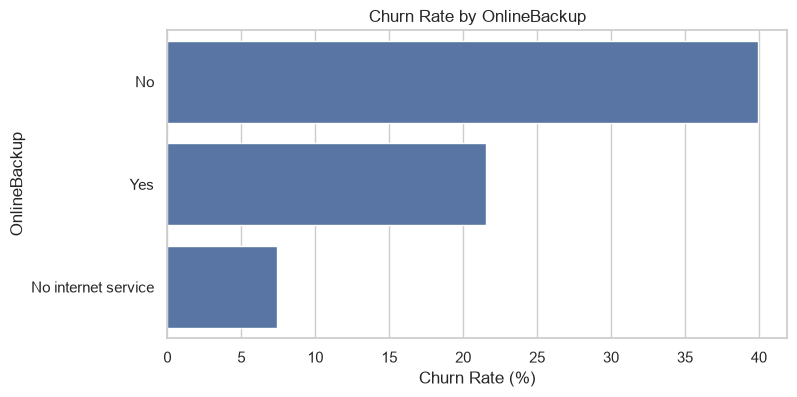

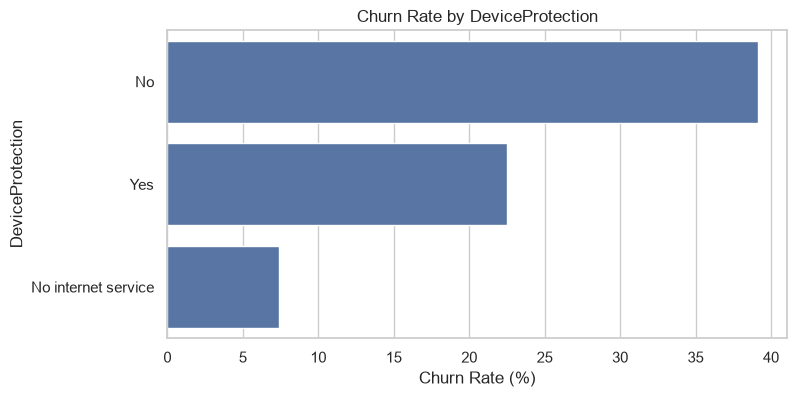

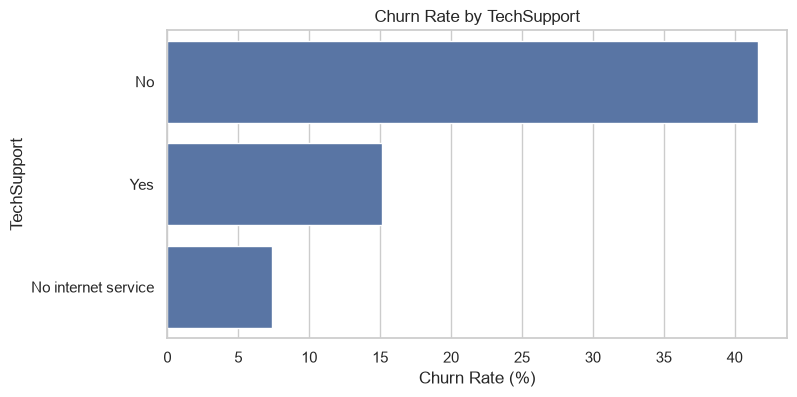

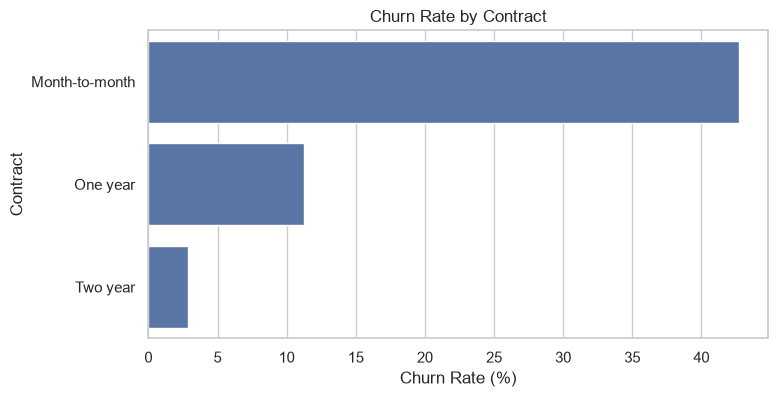

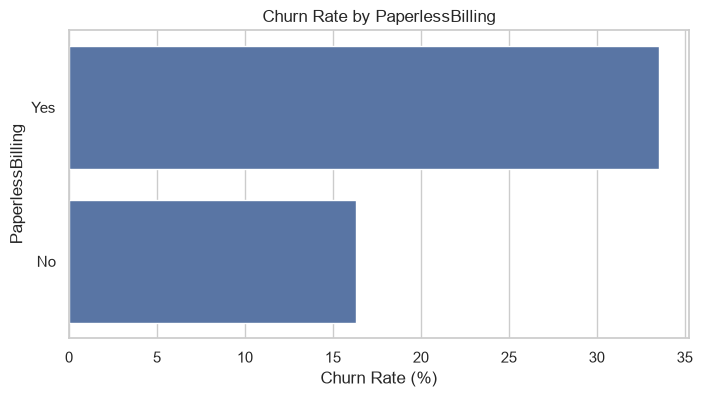

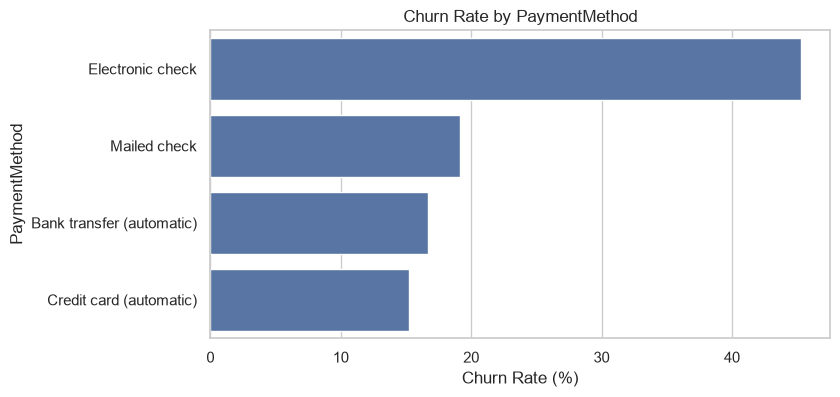

In [8]:
categorical_analysis = [
    "gender", "SeniorCitizenLabel", "Partner", "Dependents",
    "InternetService", "OnlineSecurity", "OnlineBackup",
    "DeviceProtection", "TechSupport", "Contract",
    "PaperlessBilling", "PaymentMethod"
]

for col in categorical_analysis:
    rates = df.groupby(col)["ChurnBinary"].mean().mul(100).sort_values(ascending=False)
    plt.figure(figsize=(8, 4))
    sns.barplot(x=rates.values, y=rates.index)
    plt.title(f"Churn Rate by {col}")
    plt.xlabel("Churn Rate (%)")
    plt.ylabel(col)
    plt.show()


## 7. Tenure Analysis

,count,mean,churn_rate_pct
TenureGroup,,,
0–6,1481,0.529,52.937
7–12,705,0.359,35.887
13–24,1024,0.287,28.711
25–48,1594,0.204,20.389
49–72,2239,0.095,9.513


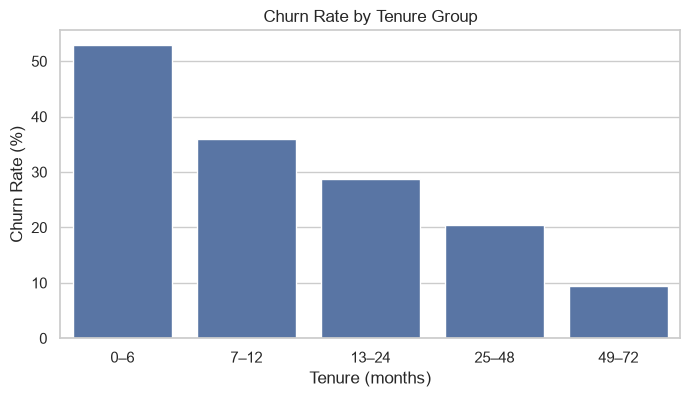

In [9]:
bins = [-1, 6, 12, 24, 48, 72]
labels = ["0–6", "7–12", "13–24", "25–48", "49–72"]
df["TenureGroup"] = pd.cut(df["tenure"], bins=bins, labels=labels)

tenure_churn = df.groupby("TenureGroup", observed=True)["ChurnBinary"].agg(["count", "mean"])
tenure_churn["churn_rate_pct"] = tenure_churn["mean"] * 100
display(tenure_churn.round(3))

plt.figure(figsize=(8, 4))
sns.barplot(data=tenure_churn.reset_index(), x="TenureGroup", y="churn_rate_pct")
plt.title("Churn Rate by Tenure Group")
plt.xlabel("Tenure (months)")
plt.ylabel("Churn Rate (%)")
plt.show()


## 8. Monthly Charges vs Churn

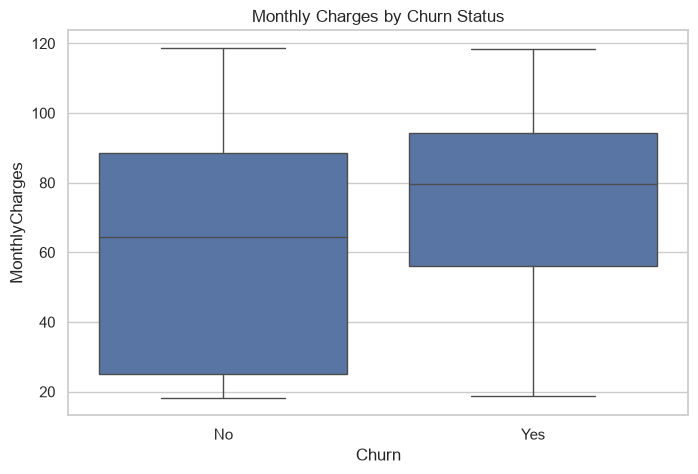

,mean,median,std
Churn,,,
No,61.27,64.43,31.09
Yes,74.44,79.65,24.67


In [10]:
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x="Churn", y="MonthlyCharges")
plt.title("Monthly Charges by Churn Status")
plt.show()

display(df.groupby("Churn")["MonthlyCharges"].agg(["mean", "median", "std"]).round(2))


## 9. Multivariate Analysis

InternetService,DSL,Fiber optic,No
Contract,,,
Month-to-month,32.22,54.61,18.89
One year,9.30,19.29,2.47
Two year,1.91,7.23,0.78


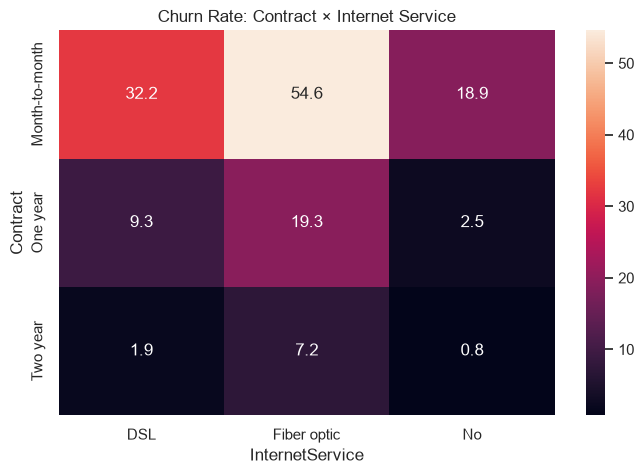

In [11]:
pivot = pd.pivot_table(
    df, values="ChurnBinary",
    index="Contract", columns="InternetService",
    aggfunc="mean"
) * 100

display(pivot.round(2))

plt.figure(figsize=(8, 5))
sns.heatmap(pivot, annot=True, fmt=".1f")
plt.title("Churn Rate: Contract × Internet Service")
plt.show()


## 10. Correlation Analysis

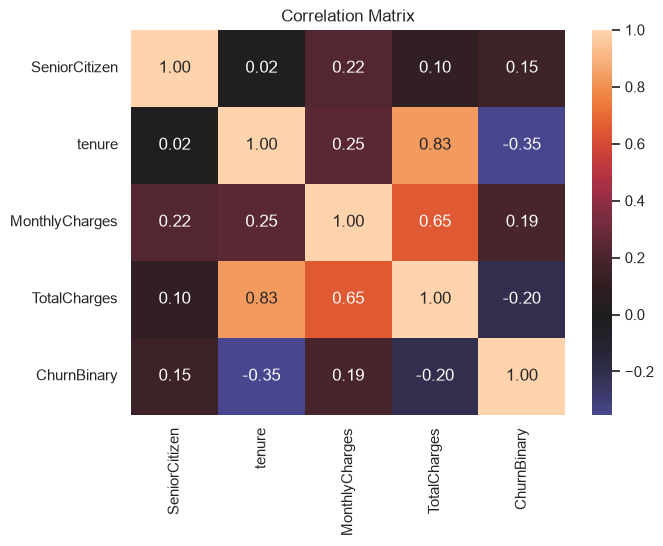

In [12]:
corr_cols = ["SeniorCitizen", "tenure", "MonthlyCharges", "TotalCharges", "ChurnBinary"]
corr = df[corr_cols].corr()

plt.figure(figsize=(7, 5))
sns.heatmap(corr, annot=True, fmt=".2f", center=0)
plt.title("Correlation Matrix")
plt.show()


## 11. Statistical Hypothesis Testing

For categorical variables, the Chi-square test checks whether the variable and churn are statistically independent.

- H0: the variable and churn are independent
- H1: the variable and churn are associated


In [13]:
chi_results = []

for col in categorical_analysis:
    table = pd.crosstab(df[col], df["Churn"])
    chi2, p, dof, expected = chi2_contingency(table)
    chi_results.append({
        "Variable": col,
        "Chi2": chi2,
        "p_value": p,
        "Significant_at_0.05": p < 0.05
    })

chi_df = pd.DataFrame(chi_results).sort_values("p_value")
display(chi_df)


,Variable,Chi2,p_value,Significant_at_0.05
9,Contract,1184.596572,5.863038e-258,True
5,OnlineSecurity,849.998968,2.661150e-185,True
8,TechSupport,828.197068,1.443084e-180,True
4,InternetService,732.309590,9.571788e-160,True
11,PaymentMethod,648.142327,3.682355e-140,True
6,OnlineBackup,601.812790,2.079759e-131,True
7,DeviceProtection,558.419369,5.505219e-122,True
10,PaperlessBilling,258.277649,4.073355e-58,True
3,Dependents,189.129249,4.924922e-43,True
1,SeniorCitizenLabel,159.426300,1.510067e-36,True


### Numerical hypothesis tests

In [14]:
ttest_results = []

for col in ["tenure", "MonthlyCharges", "TotalCharges"]:
    no_churn = df.loc[df["Churn"] == "No", col].dropna()
    churn = df.loc[df["Churn"] == "Yes", col].dropna()
    stat, p = ttest_ind(no_churn, churn, equal_var=False)
    ttest_results.append({
        "Variable": col,
        "t_statistic": stat,
        "p_value": p,
        "Significant_at_0.05": p < 0.05
    })

display(pd.DataFrame(ttest_results))


,Variable,t_statistic,p_value,Significant_at_0.05
0,tenure,34.823819,1.195495e-232,True
1,MonthlyCharges,-18.407527,8.592449e-73,True
2,TotalCharges,18.800768,1.152494e-75,True


## 12. Customer Segmentation with K-Means

Segmentation uses tenure, monthly charges, and total charges. The churn target is not used to create the clusters.


In [15]:
seg_cols = ["tenure", "MonthlyCharges", "TotalCharges"]
seg_data = SimpleImputer(strategy="median").fit_transform(df[seg_cols])
seg_scaled = StandardScaler().fit_transform(seg_data)

scores = {}
for k in range(2, 7):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(seg_scaled)
    scores[k] = silhouette_score(seg_scaled, labels_k)

display(pd.DataFrame({
    "k": list(scores.keys()),
    "silhouette_score": list(scores.values())
}))

best_k = max(scores, key=scores.get)
print("Best k:", best_k)

kmeans = KMeans(n_clusters=best_k, random_state=42, n_init=10)
df["Segment"] = kmeans.fit_predict(seg_scaled)

segment_summary = df.groupby("Segment")[seg_cols + ["ChurnBinary"]].mean().round(2)
segment_summary["ChurnRatePct"] = segment_summary["ChurnBinary"] * 100
display(segment_summary)


,k,silhouette_score
0,2,0.479731
1,3,0.451358
2,4,0.471967
3,5,0.443509
4,6,0.437463


Best k: 2


,tenure,MonthlyCharges,TotalCharges,ChurnBinary,ChurnRatePct
Segment,,,,,
0,20.03,52.17,868.07,0.31,31.0
1,56.87,89.76,5084.99,0.17,17.0


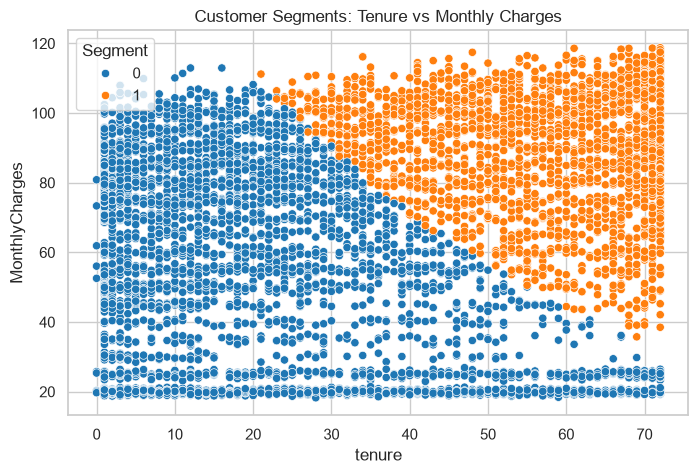

In [16]:
plt.figure(figsize=(8, 5))
sns.scatterplot(
    data=df, x="tenure", y="MonthlyCharges",
    hue="Segment", palette="tab10"
)
plt.title("Customer Segments: Tenure vs Monthly Charges")
plt.show()


## 13. Machine Learning Preparation

In [17]:
drop_cols = [
    "customerID", "Churn", "ChurnBinary",
    "SeniorCitizenLabel", "TenureGroup", "Segment"
]

X = df.drop(columns=drop_cols)
y = df["ChurnBinary"]

categorical_features = X.select_dtypes(include=["object"]).columns.tolist()
numeric_features = X.select_dtypes(include=[np.number]).columns.tolist()

numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipeline, numeric_features),
    ("cat", categorical_pipeline, categorical_features)
])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("Training:", X_train.shape)
print("Testing:", X_test.shape)


Training: (5634, 19)
Testing: (1409, 19)


## 14. Train Classification Models

In [18]:
models = {
    "Logistic Regression": LogisticRegression(
        max_iter=2000, class_weight="balanced"
    ),
    "Random Forest": RandomForestClassifier(
        n_estimators=400, random_state=42,
        class_weight="balanced", n_jobs=-1
    ),
    "Gradient Boosting": GradientBoostingClassifier(random_state=42)
}

results = []
fitted_models = {}

for name, model in models.items():
    pipe = Pipeline([
        ("preprocessor", preprocessor),
        ("model", model)
    ])

    pipe.fit(X_train, y_train)
    fitted_models[name] = pipe

    pred = pipe.predict(X_test)
    proba = pipe.predict_proba(X_test)[:, 1]

    results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, pred),
        "Precision": precision_score(y_test, pred, zero_division=0),
        "Recall": recall_score(y_test, pred, zero_division=0),
        "F1": f1_score(y_test, pred, zero_division=0),
        "ROC_AUC": roc_auc_score(y_test, proba)
    })

model_results = pd.DataFrame(results).sort_values("ROC_AUC", ascending=False)
display(model_results.round(3))


,Model,Accuracy,Precision,Recall,F1,ROC_AUC
2,Gradient Boosting,0.806,0.674,0.524,0.589,0.843
0,Logistic Regression,0.738,0.504,0.783,0.614,0.841
1,Random Forest,0.765,0.551,0.626,0.586,0.822


## 15. Classification Reports and Confusion Matrices

Logistic Regression
              precision    recall  f1-score   support

    No Churn      0.902     0.722     0.802      1035
       Churn      0.504     0.783     0.614       374

    accuracy                          0.738      1409
   macro avg      0.703     0.753     0.708      1409
weighted avg      0.797     0.738     0.752      1409



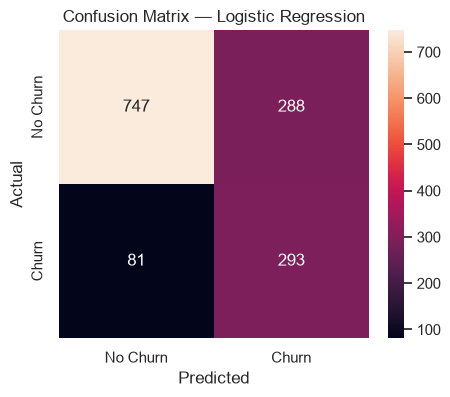

Random Forest
              precision    recall  f1-score   support

    No Churn      0.858     0.815     0.836      1035
       Churn      0.551     0.626     0.586       374

    accuracy                          0.765      1409
   macro avg      0.704     0.721     0.711      1409
weighted avg      0.776     0.765     0.770      1409



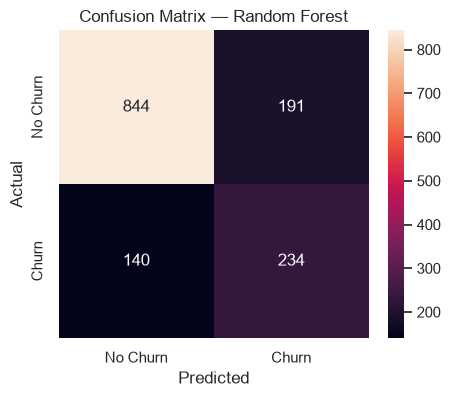

Gradient Boosting
              precision    recall  f1-score   support

    No Churn      0.841     0.908     0.873      1035
       Churn      0.674     0.524     0.589       374

    accuracy                          0.806      1409
   macro avg      0.757     0.716     0.731      1409
weighted avg      0.796     0.806     0.798      1409



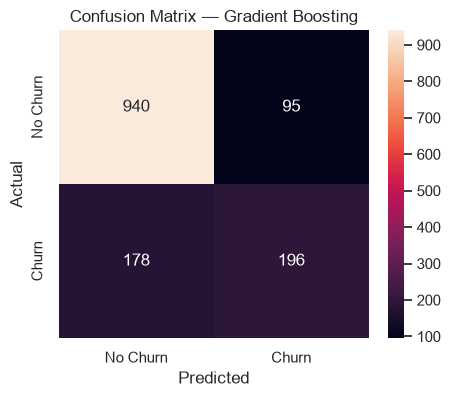

In [19]:
for name, pipe in fitted_models.items():
    pred = pipe.predict(X_test)

    print("=" * 70)
    print(name)
    print("=" * 70)
    print(classification_report(
        y_test, pred,
        target_names=["No Churn", "Churn"],
        digits=3
    ))

    cm = confusion_matrix(y_test, pred)

    plt.figure(figsize=(5, 4))
    sns.heatmap(
        cm, annot=True, fmt="d",
        xticklabels=["No Churn", "Churn"],
        yticklabels=["No Churn", "Churn"]
    )
    plt.title(f"Confusion Matrix — {name}")
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()


## 16. ROC Curves

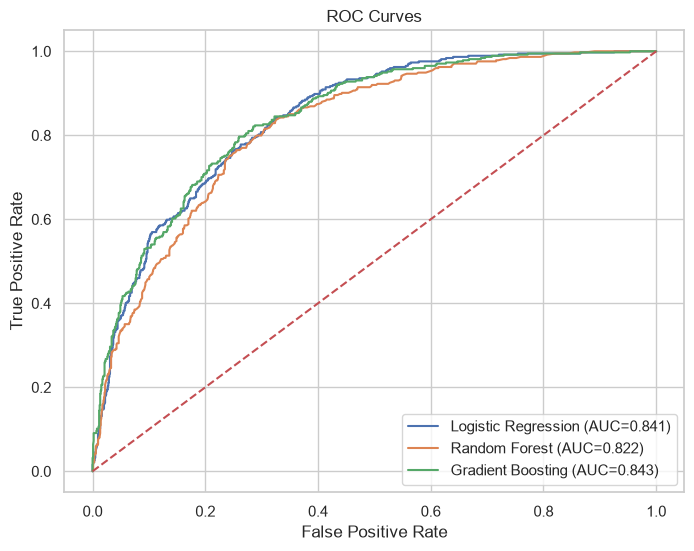

In [20]:
plt.figure(figsize=(8, 6))

for name, pipe in fitted_models.items():
    proba = pipe.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    auc = roc_auc_score(y_test, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={auc:.3f})")

plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()


## 17. Feature Importance

Random Forest


,Feature,Importance
3,num__TotalCharges,0.142535
1,num__tenure,0.131647
2,num__MonthlyCharges,0.122467
36,cat__Contract_Month-to-month,0.072038
38,cat__Contract_Two year,0.036681
18,cat__OnlineSecurity_No,0.036530
27,cat__TechSupport_No,0.033001
16,cat__InternetService_Fiber optic,0.027973
43,cat__PaymentMethod_Electronic check,0.027856
21,cat__OnlineBackup_No,0.016870


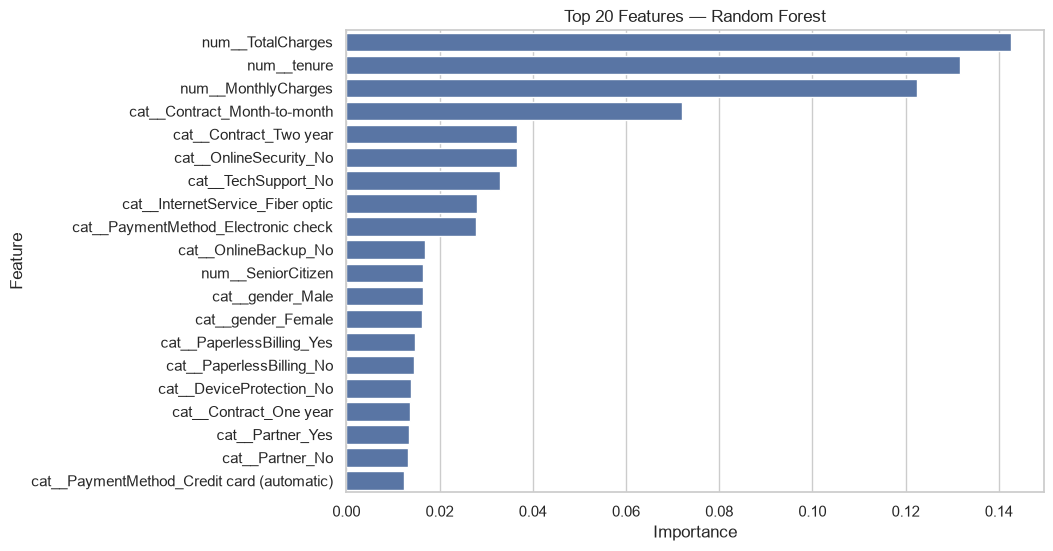

Gradient Boosting


,Feature,Importance
36,cat__Contract_Month-to-month,0.379964
1,num__tenure,0.138682
16,cat__InternetService_Fiber optic,0.086542
3,num__TotalCharges,0.085875
2,num__MonthlyCharges,0.082082
18,cat__OnlineSecurity_No,0.068142
43,cat__PaymentMethod_Electronic check,0.044309
27,cat__TechSupport_No,0.037884
40,cat__PaperlessBilling_Yes,0.011612
12,cat__MultipleLines_No,0.010302


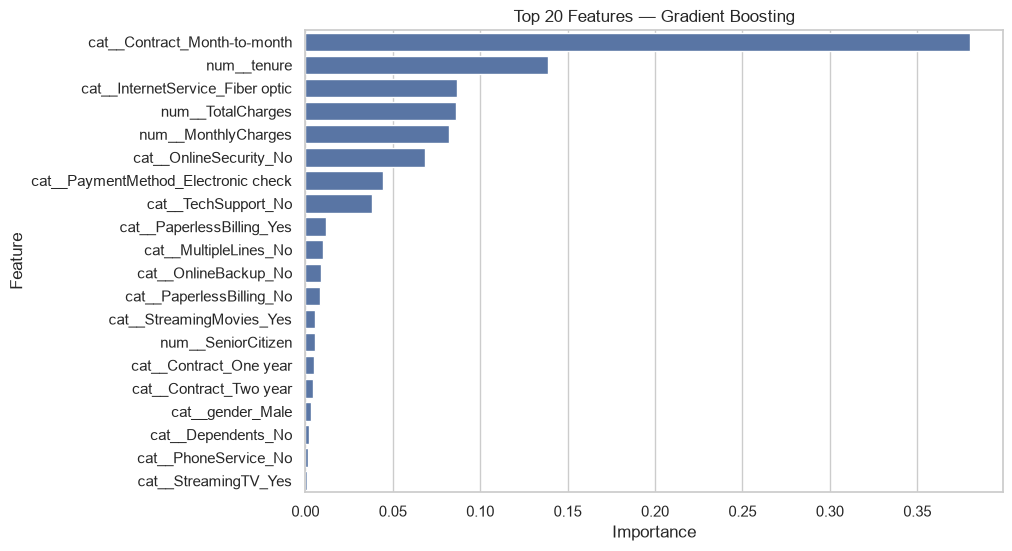

In [21]:
def get_feature_names(pipe):
    return pipe.named_steps["preprocessor"].get_feature_names_out()

for name in ["Random Forest", "Gradient Boosting"]:
    pipe = fitted_models[name]
    model = pipe.named_steps["model"]

    importance_df = pd.DataFrame({
        "Feature": get_feature_names(pipe),
        "Importance": model.feature_importances_
    }).sort_values("Importance", ascending=False).head(20)

    print(name)
    display(importance_df)

    plt.figure(figsize=(9, 6))
    sns.barplot(data=importance_df, x="Importance", y="Feature")
    plt.title(f"Top 20 Features — {name}")
    plt.show()


## 18. Business-Oriented High-Risk Segment

In [22]:
high_risk = df[
    (df["Contract"] == "Month-to-month") &
    (df["tenure"] <= 12) &
    (df["MonthlyCharges"] >= df["MonthlyCharges"].median())
].copy()

print("High-risk screening segment size:", len(high_risk))
print("Share of customers:", round(len(high_risk) / len(df) * 100, 2), "%")
print("Churn rate:", round(high_risk["ChurnBinary"].mean() * 100, 2), "%")

display(high_risk[[
    "Contract", "tenure", "MonthlyCharges",
    "InternetService", "PaymentMethod", "Churn"
]].head(10))


High-risk screening segment size: 816
Share of customers: 11.59 %
Churn rate: 69.73 %


,Contract,tenure,MonthlyCharges,InternetService,PaymentMethod,Churn
4,Month-to-month,2,70.70,Fiber optic,Electronic check,Yes
5,Month-to-month,8,99.65,Fiber optic,Electronic check,Yes
31,Month-to-month,2,95.50,Fiber optic,Credit card (automatic),No
39,Month-to-month,11,97.85,Fiber optic,Bank transfer (automatic),Yes
47,Month-to-month,2,80.65,Fiber optic,Electronic check,Yes
53,Month-to-month,8,80.65,Fiber optic,Credit card (automatic),Yes
64,Month-to-month,9,94.40,Fiber optic,Electronic check,Yes
65,Month-to-month,3,75.30,DSL,Electronic check,No
69,Month-to-month,10,79.85,Fiber optic,Mailed check,No
80,Month-to-month,1,79.35,Fiber optic,Electronic check,Yes


## 19. Key Findings and Recommendations

Use the notebook outputs to support the final report.

### Key findings
- Churn affects a substantial minority of customers.
- Month-to-month contracts are associated with substantially higher churn.
- New customers have much higher churn than long-tenure customers.
- Higher monthly charges are associated with churn.
- Electronic-check customers are a high-churn group.
- Lack of online security and technical support is associated with higher churn.
- Fiber-optic customers show higher churn in this dataset; this should be investigated alongside price and contract variables.

### Recommended retention actions
1. Strengthen onboarding during the first 6–12 months.
2. Target high-risk month-to-month customers with contract migration offers.
3. Investigate price/value perception among high-charge customers.
4. Promote technical support and online security as retention-oriented bundles.
5. Use churn probabilities to prioritize retention resources.
6. Test retention interventions experimentally rather than assuming associations are causal.


## 20. Suggested Final Report Structure

1. Introduction
2. Business Problem
3. Dataset Description
4. Data Cleaning
5. Exploratory Data Analysis
6. Churn Drivers
7. Statistical Hypothesis Testing
8. Customer Segmentation
9. Machine Learning Models
10. Model Evaluation
11. Feature Importance
12. Business Insights
13. Retention Recommendations
14. Conclusion
15. Future Scope

### Future Scope
- Hyperparameter tuning
- XGBoost/LightGBM comparison
- SHAP explainability
- Cost-sensitive threshold optimization
- Customer Lifetime Value modeling
- Retention campaign simulation
- A/B testing
